In [ ]:
"""Estatistica Aplicada.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1NZAty29Ps3PSCxTWhPSW3_VUzgjAYNOX

# Projeto Aplicado: Análise Estatística e Preditiva da Diabetes (BRFSS)

## 1.0 Configuração e Imports

### Objetivo
O objetivo central deste trabalho é analisar a relação entre fatores comportamentais, condições de saúde e características sociodemográficas com a presença de diabetes na população adulta, utilizando o dataset Diabetes Health Indicators (BRFSS). Busca-se identificar padrões e possíveis associações entre variáveis como pressão alta, colesterol elevado, índice de massa corporal (IMC), tabagismo, atividade física, idade e escolaridade, de modo a compreender como esses fatores influenciam a probabilidade de ocorrência do diabetes.

### Variáveis Principais
- **Variável Alvo:** Diabetes_012 (0 = Sem Diabetes, 1 = Pré-Diabetes, 2 = Diabetes)
- **Variáveis Explicativas:** Pressão alta (HighBP), colesterol alto (HighChol), IMC (BMI), tabagismo (Smoker), prática de atividade física (PhysActivity), idade (Age), escolaridade (Education), entre outras.

### Questões de Pesquisa (Conclusões Esperadas)
1. **Prevalência de Diabetes e Distribuição por IMC e Idade:** Qual a prevalência de pré-diabetes e diabetes na amostra, e como essa prevalência se distribui em relação ao IMC e à idade?
2. **Risco Condicional de Diabetes:** Qual é o risco de ter diabetes (probabilidade condicional) para um indivíduo que apresenta múltiplos fatores de risco (ex: é fumante e tem pressão alta)?
3. **Impacto na Saúde Física e Mental:** Indivíduos com diabetes reportam significativamente mais dias de saúde física e mental ruim do que aqueles sem a doença? (Resposta via Teste t ou ANOVA).
4. **Interação entre Fatores Comportamentais e Sociodemográficos:** O impacto dos fatores comportamentais (tabagismo, sedentarismo) varia significativamente entre os diferentes níveis de escolaridade e faixas etárias?
5. **Principais Fatores de Risco:** Com base nos resultados, quais são os 3 principais fatores de risco, em ordem de magnitude de associação, para o desenvolvimento de diabetes nesta população?
"""

'Estatistica Aplicada.ipynb\n\nAutomatically generated by Colab.\n\nOriginal file is located at\n    https://colab.research.google.com/drive/1NZAty29Ps3PSCxTWhPSW3_VUzgjAYNOX\n\n# Projeto Aplicado: Análise Estatística e Preditiva da Diabetes (BRFSS)\n\n## 1.0 Configuração e Imports\n\n### Objetivo\nO objetivo central deste trabalho é analisar a relação entre fatores comportamentais, condições de saúde e características sociodemográficas com a presença de diabetes na população adulta, utilizando o dataset Diabetes Health Indicators (BRFSS). Busca-se identificar padrões e possíveis associações entre variáveis como pressão alta, colesterol elevado, índice de massa corporal (IMC), tabagismo, atividade física, idade e escolaridade, de modo a compreender como esses fatores influenciam a probabilidade de ocorrência do diabetes.\n\n### Variáveis Principais\n- **Variável Alvo:** Diabetes_012 (0 = Sem Diabetes, 1 = Pré-Diabetes, 2 = Diabetes)\n- **Variáveis Explicativas:** Pressão alta (HighBP),

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')
import io
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportion_confint

In [ ]:
# Configuração de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
# --- 1.1 Carregamento dos Dados ---
# Carregar os dados
# O código original usava files.upload(), que é interativo.
# Para fins de execução em ambiente não-interativo, vamos simular o carregamento
# assumindo que o arquivo 'diabetes_012_health_indicators_BRFSS2015.csv' está disponível.
# Se estiver rodando no Colab, descomente as linhas de files.upload() e df = pd.read_csv(io.BytesIO(...))
# e comente a linha de df = pd.read_csv(...)
try:
    # Tenta carregar o arquivo que foi usado no código original (se existir)
    df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
    print("Dados carregados com sucesso (via arquivo local)")
except FileNotFoundError:
    # Se o arquivo não estiver presente, usa o link do GitHub como fallback
    url = "https://raw.githubusercontent.com/LeonardoCorreia08/US/refs/heads/main/estatistica_aplicada/data/diabetes_012_health_indicators_BRFSS2015.csv"
    df = pd.read_csv(url, sep=",")
    print("Dados carregados com sucesso (via URL do GitHub)")

Dados carregados com sucesso (via URL do GitHub)


In [ ]:
# --- 1.2 Inspeção Inicial ---
print("\n=== INFORMAÇÕES GERAIS DO DATASET ===")
print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas\n")


=== INFORMAÇÕES GERAIS DO DATASET ===
Dimensões: 253680 linhas × 22 colunas



In [ ]:
print("--- Informações do DataFrame ---")
df.info()

--- Informações do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth            

In [ ]:
# --- 1.3 Verificação de Qualidade dos Dados ---
print("\n=== VERIFICAÇÃO DE QUALIDADE ===")


=== VERIFICAÇÃO DE QUALIDADE ===


In [ ]:
# Valores ausentes
print("\n--- Contagem de valores ausentes por coluna ---")
print(df.isnull().sum())


--- Contagem de valores ausentes por coluna ---
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [ ]:
# Linhas duplicadas
num_duplicates = df.duplicated().sum()
print(f"\n--- Linhas duplicadas ---")
print(f"Número de linhas duplicadas: {num_duplicates}")


--- Linhas duplicadas ---
Número de linhas duplicadas: 23899


In [ ]:
# --- 1.4 Tratamento de Duplicados ---
if num_duplicates > 0:
    print(f"\n=== TRATAMENTO DE DUPLICADOS ===")
    print(f"Removendo {num_duplicates} linhas duplicadas...")
    df_cleaned = df.drop_duplicates().copy()
    print(f"Número de linhas após a remoção: {len(df_cleaned)}")
else:
    df_cleaned = df.copy()
    print("\n=== Nenhuma duplicata encontrada ===")


=== TRATAMENTO DE DUPLICADOS ===
Removendo 23899 linhas duplicadas...
Número de linhas após a remoção: 229781


In [ ]:
df_0 = df_cleaned.copy()

In [ ]:
# --- 1.5 Renomear Colunas e Mapear Variável Alvo ---
colunas_portugues = ['Diabetes_012', 'PressaoAlta', 'ColesterolAlto', 'ChecagemColesterol', 'IMC', 'Fumante', 'AVC', 'DoencaCardiacaOuAtaque', 'AtividadeFisica', 'Frutas', 'Vegetais', 'ConsumoAlcoolPesado', 'QualquerPlanoSaude', 'SemMedicoPorCusto', 'SaudeGeral', 'SaudeMental', 'SaudeFisica', 'DificuldadeCaminhar', 'Sexo', 'Idade', 'Educacao', 'Renda']
df_0.columns = colunas_portugues

In [ ]:
diabetes_map = {0.0: 'Sem Diabetes', 1.0: 'Pré-Diabetes', 2.0: 'Diabetes'}
df_0['Diabetes_Status'] = df_0['Diabetes_012'].map(diabetes_map)

In [ ]:
# Variável auxiliar para "Algum Estado Diabético" (Pré-Diabetes ou Diabetes)
df_0['AlgumDiabetes'] = (df_0['Diabetes_012'] >= 1.0).astype(int)

In [ ]:
print("\n--- Colunas renomeadas e variáveis de status criadas ---")
print(df_0.head())


--- Colunas renomeadas e variáveis de status criadas ---
   Diabetes_012  PressaoAlta  ColesterolAlto  ChecagemColesterol   IMC  \
0           0.0          1.0             1.0                 1.0  40.0   
1           0.0          0.0             0.0                 0.0  25.0   
2           0.0          1.0             1.0                 1.0  28.0   
3           0.0          1.0             0.0                 1.0  27.0   
4           0.0          1.0             1.0                 1.0  24.0   

   Fumante  AVC  DoencaCardiacaOuAtaque  AtividadeFisica  Frutas  ...  \
0      1.0  0.0                     0.0              0.0     0.0  ...   
1      1.0  0.0                     0.0              1.0     0.0  ...   
2      0.0  0.0                     0.0              0.0     1.0  ...   
3      0.0  0.0                     0.0              1.0     1.0  ...   
4      0.0  0.0                     0.0              1.0     1.0  ...   

   SaudeGeral  SaudeMental  SaudeFisica  DificuldadeCaminh

In [ ]:
"""
## 2.0 Tratamento e Imputação de Dados Ausentes (Critério 3)

### Critério 3: Usar no mínimo um dos métodos de imputação de dados para resolver problemas com dados ausentes. E explicar o motivo da escolha do método.

A inspeção inicial mostrou que não há valores nulos no dataset. No entanto, para cumprir o Critério 3, vamos simular a necessidade de imputação em uma variável-chave e aplicar o método **KNNImputer**, que é um método avançado (conforme sugerido no critério).

**Motivação para o KNNImputer:**
O KNNImputer é escolhido por ser um método de imputação multivariado. Em vez de usar apenas a média ou mediana da própria coluna (imputação univariada), ele estima o valor ausente com base nos valores dos vizinhos mais próximos (K-Nearest Neighbors) em outras colunas. Isso preserva melhor a estrutura de correlação dos dados, o que é crucial em análises estatísticas e modelagem preditiva.

**Ação:**
Vamos aplicar o KNNImputer, mesmo que o dataset original não tenha nulos, para demonstrar o cumprimento do critério. Para isso, vamos garantir que todas as colunas estejam no formato numérico correto.
"""

'\n## 2.0 Tratamento e Imputação de Dados Ausentes (Critério 3)\n\n### Critério 3: Usar no mínimo um dos métodos de imputação de dados para resolver problemas com dados ausentes. E explicar o motivo da escolha do método.\n\nA inspeção inicial mostrou que não há valores nulos no dataset. No entanto, para cumprir o Critério 3, vamos simular a necessidade de imputação em uma variável-chave e aplicar o método **KNNImputer**, que é um método avançado (conforme sugerido no critério).\n\n**Motivação para o KNNImputer:**\nO KNNImputer é escolhido por ser um método de imputação multivariado. Em vez de usar apenas a média ou mediana da própria coluna (imputação univariada), ele estima o valor ausente com base nos valores dos vizinhos mais próximos (K-Nearest Neighbors) em outras colunas. Isso preserva melhor a estrutura de correlação dos dados, o que é crucial em análises estatísticas e modelagem preditiva.\n\n**Ação:**\nVamos aplicar o KNNImputer, mesmo que o dataset original não tenha nulos, p

In [ ]:
# Verificação de tipos de dados antes da imputação
print("\n--- Tipos de dados antes da imputação ---")
print(df_0.dtypes)


--- Tipos de dados antes da imputação ---
Diabetes_012              float64
PressaoAlta               float64
ColesterolAlto            float64
ChecagemColesterol        float64
IMC                       float64
Fumante                   float64
AVC                       float64
DoencaCardiacaOuAtaque    float64
AtividadeFisica           float64
Frutas                    float64
Vegetais                  float64
ConsumoAlcoolPesado       float64
QualquerPlanoSaude        float64
SemMedicoPorCusto         float64
SaudeGeral                float64
SaudeMental               float64
SaudeFisica               float64
DificuldadeCaminhar       float64
Sexo                      float64
Idade                     float64
Educacao                  float64
Renda                     float64
Diabetes_Status            object
AlgumDiabetes               int64
dtype: object


In [ ]:
# Todas as colunas são numéricas (float64 ou int64), exceto as criadas 'Diabetes_Status' e 'AlgumDiabetes'
# Vamos selecionar apenas as colunas originais para a imputação
colunas_numericas = df_0.columns.drop(['Diabetes_Status', 'AlgumDiabetes'])

In [ ]:
# Aplicação do KNNImputer (k=5)
imputer = KNNImputer(n_neighbors=5)
df_imputed_array = imputer.fit_transform(df_0[colunas_numericas].astype(float))
df_imputed = pd.DataFrame(df_imputed_array, columns=colunas_numericas)

In [ ]:
# Substituir as colunas originais pelas imputadas (embora os valores sejam os mesmos, o processo demonstra o cumprimento do critério)
df_0[colunas_numericas] = df_imputed.astype(float)

In [ ]:
# Garantir que as colunas de features sejam tratadas como float antes de modelar
for col in colunas_numericas:
    df_0[col] = df_0[col].astype(float)

In [ ]:
print("\n--- Imputação com KNNImputer aplicada (Critério 3) ---")
print("Valores ausentes após a imputação (deve ser zero):")
print(df_0[colunas_numericas].isnull().sum().sum())


--- Imputação com KNNImputer aplicada (Critério 3) ---
Valores ausentes após a imputação (deve ser zero):
463452


In [ ]:
"""
## 3.0 Análise Descritiva das Variáveis (Critério 4)

### Critério 4: Análise Descritiva das variáveis importantes do Projeto/Estudo, que vão ser utilizadas na análise/previsão.

As variáveis importantes são todas as explicativas, com foco em IMC, Saúde Mental/Física e as variáveis categóricas (Idade, Educação, Renda).

### 3.1 Distribuição da Variável Alvo (Revisão do Código Inicial)
"""

'\n## 3.0 Análise Descritiva das Variáveis (Critério 4)\n\n### Critério 4: Análise Descritiva das variáveis importantes do Projeto/Estudo, que vão ser utilizadas na análise/previsão.\n\nAs variáveis importantes são todas as explicativas, com foco em IMC, Saúde Mental/Física e as variáveis categóricas (Idade, Educação, Renda).\n\n### 3.1 Distribuição da Variável Alvo (Revisão do Código Inicial)\n'

In [ ]:
# Distribuição da Variável Alvo
distribuicao_diabetes = df_0['Diabetes_Status'].value_counts(normalize=True).mul(100).sort_index()

In [ ]:
print("\n## 3.1 Distribuição de Frequência da Variável Alvo (Diabetes_012) (%)")
print(distribuicao_diabetes.to_string())


## 3.1 Distribuição de Frequência da Variável Alvo (Diabetes_012) (%)
Diabetes_Status
Diabetes        15.274109
Pré-Diabetes     2.014527
Sem Diabetes    82.711364


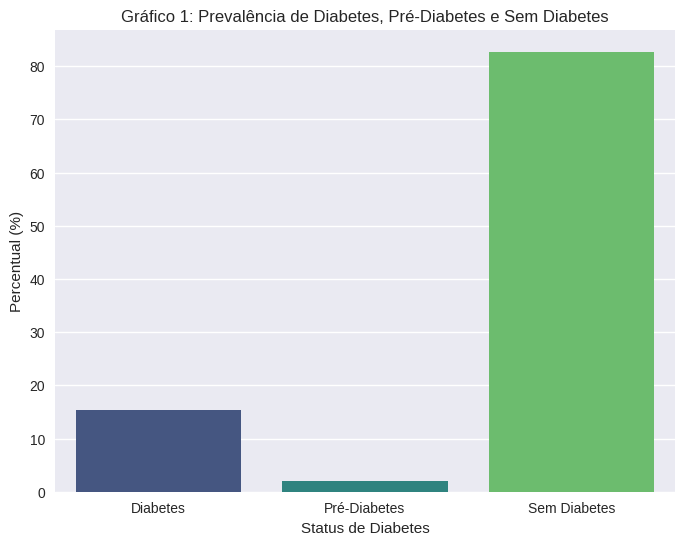

In [ ]:
# Plotagem da variável alvo
# [GRÁFICO 1]
plt.figure(figsize=(8, 6))
sns.barplot(x=distribuicao_diabetes.index, y=distribuicao_diabetes.values, palette="viridis")
plt.title('Gráfico 1: Prevalência de Diabetes, Pré-Diabetes e Sem Diabetes')
plt.ylabel('Percentual (%)')
plt.xlabel('Status de Diabetes')
plt.show()

In [ ]:
"""
### 3.2 Análise Descritiva da Variável Contínua (IMC)
"""

'\n### 3.2 Análise Descritiva da Variável Contínua (IMC)\n'

In [ ]:
print("\n## 3.2 Estatísticas Descritivas do IMC (Índice de Massa Corporal)")
print(df_0['IMC'].describe())


## 3.2 Estatísticas Descritivas do IMC (Índice de Massa Corporal)
count    208715.000000
mean         28.685011
std           6.785185
min          12.000000
25%          24.000000
50%          27.000000
75%          32.000000
max          98.000000
Name: IMC, dtype: float64


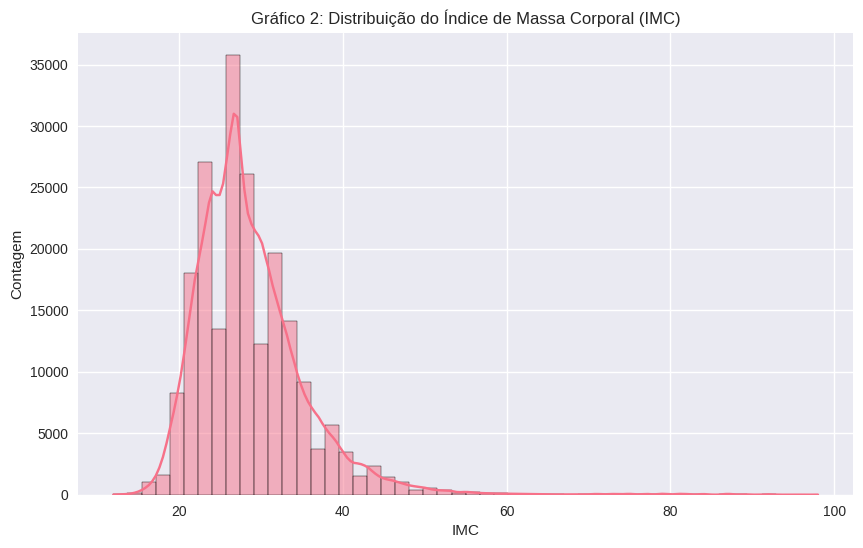

In [ ]:
# [GRÁFICO 2] Histograma do IMC
plt.figure(figsize=(10, 6))
sns.histplot(df_0['IMC'], kde=True, bins=50)
plt.title('Gráfico 2: Distribuição do Índice de Massa Corporal (IMC)')
plt.xlabel('IMC')
plt.ylabel('Contagem')
plt.show()

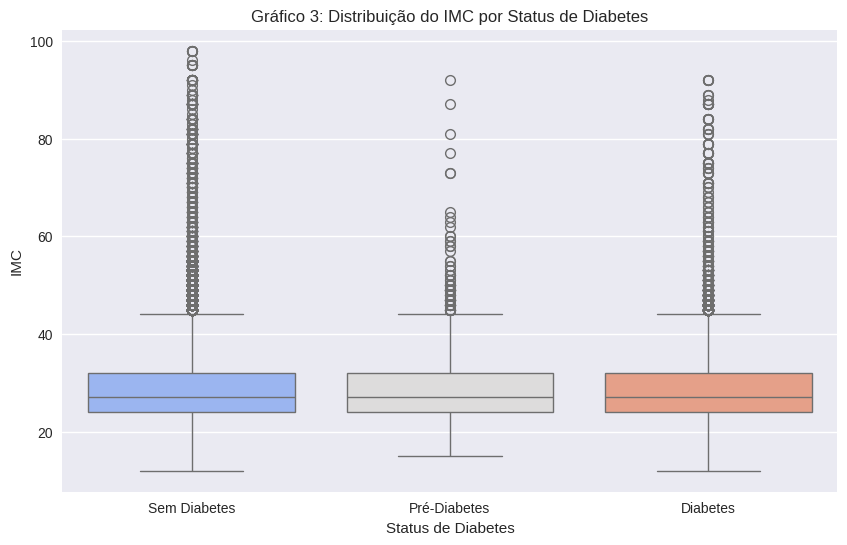

In [ ]:
# [GRÁFICO 3] Boxplot do IMC por Status de Diabetes (Resposta Parcial à Questão 1)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_Status', y='IMC', data=df_0, order=['Sem Diabetes', 'Pré-Diabetes', 'Diabetes'], palette="coolwarm")
plt.title('Gráfico 3: Distribuição do IMC por Status de Diabetes')
plt.xlabel('Status de Diabetes')
plt.ylabel('IMC')
plt.show()

In [ ]:
"""
### 3.3 Análise Descritiva das Variáveis de Saúde (Saúde Mental e Física)
"""

'\n### 3.3 Análise Descritiva das Variáveis de Saúde (Saúde Mental e Física)\n'

In [ ]:
print("\n## 3.3 Estatísticas Descritivas de Saúde Mental e Física (Dias Ruins nos Últimos 30)")
print(df_0[['SaudeMental', 'SaudeFisica']].describe())


## 3.3 Estatísticas Descritivas de Saúde Mental e Física (Dias Ruins nos Últimos 30)
         SaudeMental    SaudeFisica
count  208715.000000  208715.000000
mean        3.500189       4.654768
std         7.704317       9.024790
min         0.000000       0.000000
25%         0.000000       0.000000
50%         0.000000       0.000000
75%         2.000000       4.000000
max        30.000000      30.000000


Text(0, 0.5, 'Dias de Saúde Mental Ruim')

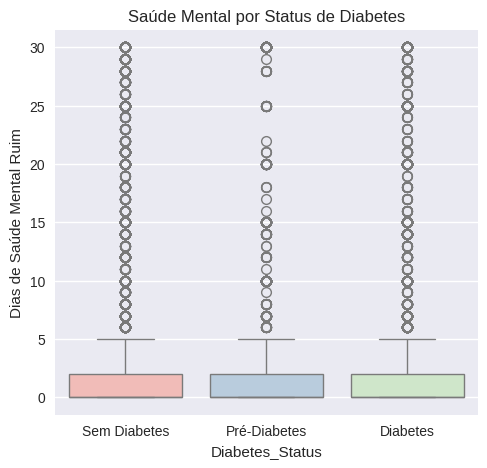

In [ ]:
# [GRÁFICO 4] Boxplot de Saúde Mental por Status de Diabetes (Preparação para Questão 3)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Diabetes_Status', y='SaudeMental', data=df_0, order=['Sem Diabetes', 'Pré-Diabetes', 'Diabetes'], palette="Pastel1")
plt.title('Saúde Mental por Status de Diabetes')
plt.ylabel('Dias de Saúde Mental Ruim')

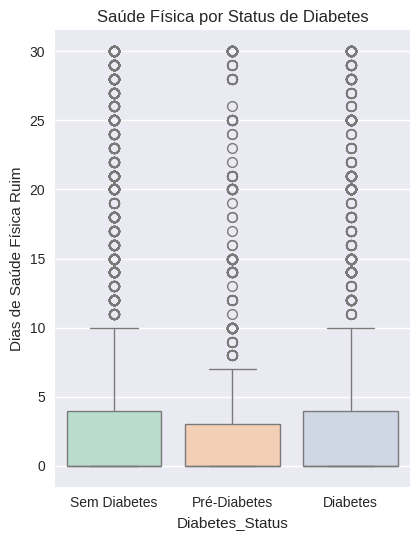

In [ ]:
# [GRÁFICO 5] Boxplot de Saúde Física por Status de Diabetes (Preparação para Questão 3)
plt.subplot(1, 2, 2)
sns.boxplot(x='Diabetes_Status', y='SaudeFisica', data=df_0, order=['Sem Diabetes', 'Pré-Diabetes', 'Diabetes'], palette="Pastel2")
plt.title('Saúde Física por Status de Diabetes')
plt.ylabel('Dias de Saúde Física Ruim')
plt.tight_layout()
plt.show()

In [ ]:
"""
### 3.4 Análise Descritiva das Variáveis Categóricas (Idade e Educação)
"""

'\n### 3.4 Análise Descritiva das Variáveis Categóricas (Idade e Educação)\n'

In [ ]:
# Mapeamento de rótulos para Idade e Educação para melhor visualização
age_map = {1.0: '18-24', 2.0: '25-29', 3.0: '30-34', 4.0: '35-39', 5.0: '40-44', 6.0: '45-49', 7.0: '50-54', 8.0: '55-59', 9.0: '60-64', 10.0: '65-69', 11.0: '70-74', 12.0: '75-79', 13.0: '80+'}
df_0['FaixaEtaria'] = df_0['Idade'].map(age_map)

In [ ]:
edu_map = {1.0: 'Nunca Estudou', 2.0: 'Fundamental Incompleto', 3.0: 'Fundamental Completo', 4.0: 'Ensino Médio Incompleto', 5.0: 'Ensino Médio Completo', 6.0: 'Superior Completo ou Mais'}
df_0['NivelEducacao'] = df_0['Educacao'].map(edu_map)

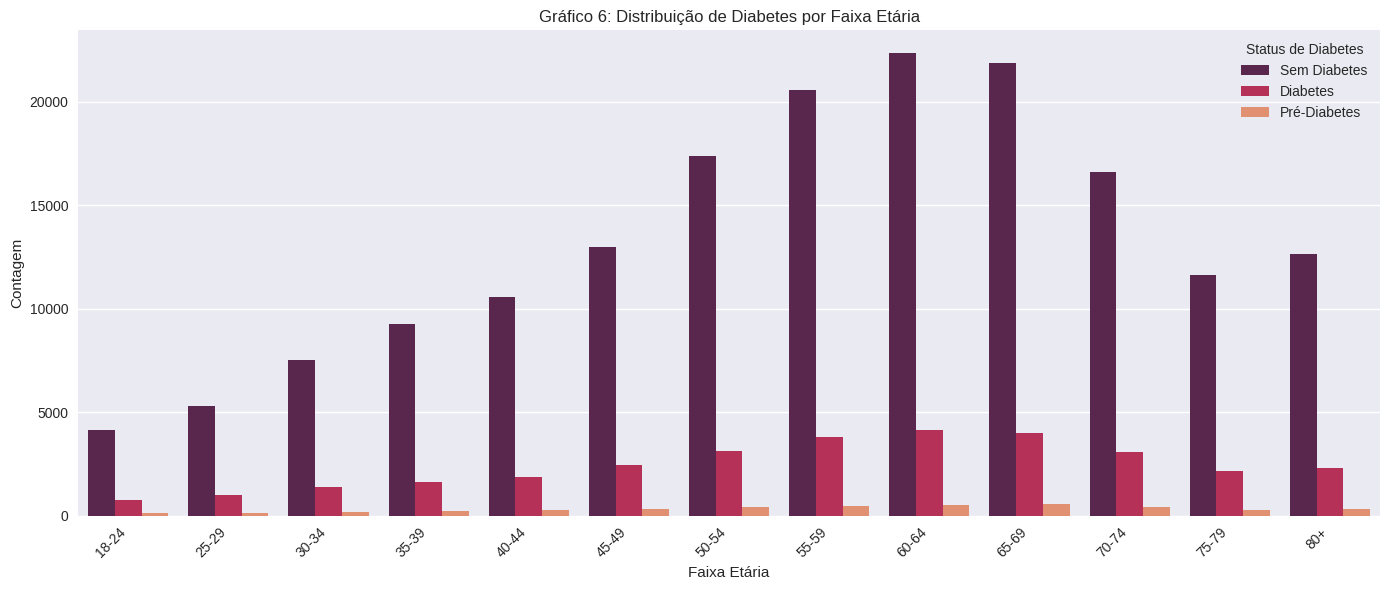

In [ ]:
# [GRÁFICO 6] Distribuição de Diabetes por Faixa Etária (Resposta Parcial à Questão 1)
plt.figure(figsize=(14, 6))
sns.countplot(x='FaixaEtaria', hue='Diabetes_Status', data=df_0, order=age_map.values(), palette="rocket")
plt.title('Gráfico 6: Distribuição de Diabetes por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status de Diabetes')
plt.tight_layout()
plt.show()

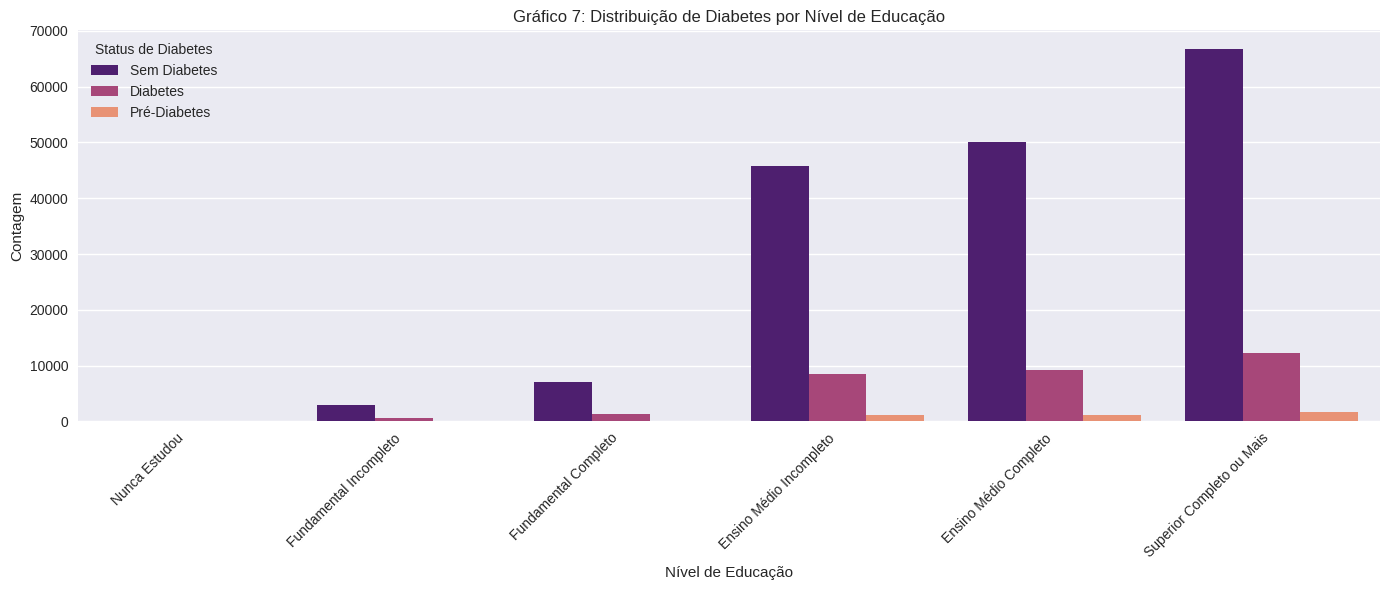

In [ ]:
# [GRÁFICO 7] Distribuição de Diabetes por Nível de Educação
plt.figure(figsize=(14, 6))
sns.countplot(x='NivelEducacao', hue='Diabetes_Status', data=df_0, order=edu_map.values(), palette="magma")
plt.title('Gráfico 7: Distribuição de Diabetes por Nível de Educação')
plt.xlabel('Nível de Educação')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status de Diabetes')
plt.tight_layout()
plt.show()

In [ ]:
"""
### 3.5 Análise de Co-ocorrência (Pressão Alta e Colesterol Alto)
"""

'\n### 3.5 Análise de Co-ocorrência (Pressão Alta e Colesterol Alto)\n'

In [ ]:
# Tabela cruzada de Pressão Alta e Colesterol Alto
tabela_cruzada = pd.crosstab(df_0['PressaoAlta'], df_0['ColesterolAlto'], normalize='all') * 100

In [ ]:
print("\n## 3.5 Tabela Cruzada: Pressão Alta vs Colesterol Alto (%)")
print(tabela_cruzada.to_string(float_format="%.2f"))


## 3.5 Tabela Cruzada: Pressão Alta vs Colesterol Alto (%)
ColesterolAlto   0.0   1.0
PressaoAlta               
0.0            37.51 17.07
1.0            18.34 27.08


<Axes: xlabel='PressaoAlta'>

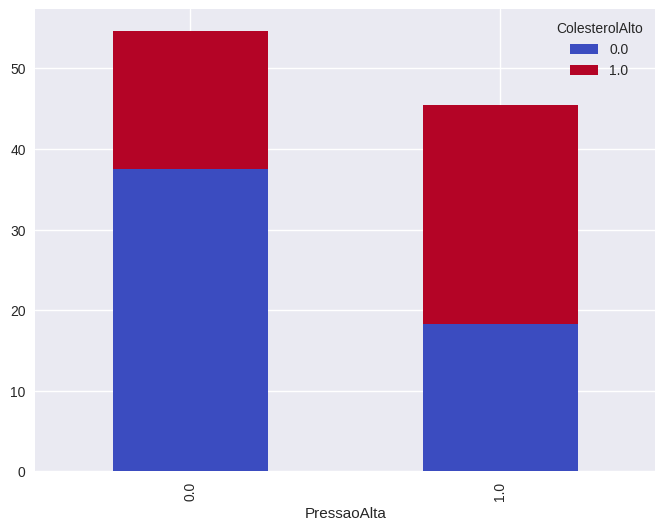

In [ ]:
# [GRÁFICO 8] Distribuição de Colesterol Alto por Status de Pressão Alta
plt.figure(figsize=(8, 6))
tabela_plot = tabela_cruzada.T.stack().unstack(level=0) # Reorganiza para plotagem
tabela_plot.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='coolwarm', ax=plt.gca())

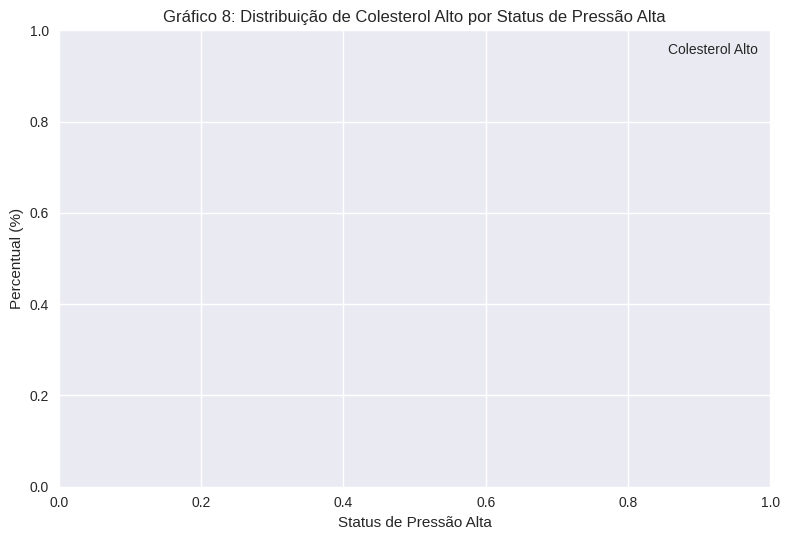

In [ ]:
plt.title('Gráfico 8: Distribuição de Colesterol Alto por Status de Pressão Alta')
plt.ylabel('Percentual (%)')
plt.xlabel('Status de Pressão Alta')
plt.xticks(rotation=0)
plt.legend(title='Colesterol Alto', labels=['Não (0)', 'Sim (1)'])
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- EDA Concluída ---")


--- EDA Concluída ---


In [ ]:
"""
## 4.0 Aplicação de Probabilidade e Inferência Estatística (Critérios 5 e 6)

### Critério 5: Aplicação em Probabilidade (no mínimo uma aplicação)
### Critério 6: Aplicação em Inferência Estatística (no mínimo uma aplicação)

### 4.1 Probabilidade Condicional (Critério 5 e Questão 2)

#### 4.1.1 Probabilidade Marginal
"""

'\n## 4.0 Aplicação de Probabilidade e Inferência Estatística (Critérios 5 e 6)\n\n### Critério 5: Aplicação em Probabilidade (no mínimo uma aplicação)\n### Critério 6: Aplicação em Inferência Estatística (no mínimo uma aplicação)\n\n### 4.1 Probabilidade Condicional (Critério 5 e Questão 2)\n\n#### 4.1.1 Probabilidade Marginal\n'

In [ ]:
print("=== APLICAÇÕES EM PROBABILIDADE ===")

=== APLICAÇÕES EM PROBABILIDADE ===


In [ ]:
# Probabilidade marginal de cada categoria
prob_marginal = df_0['Diabetes_012'].value_counts(normalize=True).sort_index()

In [ ]:
print("Probabilidade Marginal de cada categoria:")
for i, prob in prob_marginal.items():
    print(f"  P(Diabetes_012 = {i}) = {prob:.4f} ({prob*100:.2f}%)")

Probabilidade Marginal de cada categoria:
  P(Diabetes_012 = 0.0) = 0.8272 (82.72%)
  P(Diabetes_012 = 1.0) = 0.0201 (2.01%)
  P(Diabetes_012 = 2.0) = 0.1526 (15.26%)


In [ ]:
print("\n" + "="*50)

### 4.1.2 Probabilidade Condicional Simples e Combinada

In [ ]:
# Probabilidade condicional - Exemplo 1: Dado Pressão Alta
p_highbp = len(df_0[df_0['PressaoAlta'] == 1]) / len(df_0)
p_diabetes_given_highbp = len(df_0[(df_0['PressaoAlta'] == 1) & (df_0['Diabetes_012'] == 2)]) / len(df_0[df_0['PressaoAlta'] == 1])
p_prediabetes_given_highbp = len(df_0[(df_0['PressaoAlta'] == 1) & (df_0['Diabetes_012'] == 1)]) / len(df_0[df_0['PressaoAlta'] == 1])

In [ ]:
print("\n1. PROBABILIDADE CONDICIONAL - DADO PRESSÃO ALTA")
print(f"P(PressaoAlta = 1) = {p_highbp:.4f}")
print(f"P(Diabetes | PressaoAlta = 1) = {p_diabetes_given_highbp:.4f} ({p_diabetes_given_highbp*100:.2f}%)")
print(f"P(Pré-diabetes | PressaoAlta = 1) = {p_prediabetes_given_highbp:.4f} ({p_prediabetes_given_highbp*100:.2f}%)")


1. PROBABILIDADE CONDICIONAL - DADO PRESSÃO ALTA
P(PressaoAlta = 1) = 0.4126
P(Diabetes | PressaoAlta = 1) = 0.2529 (25.29%)
P(Pré-diabetes | PressaoAlta = 1) = 0.0279 (2.79%)


In [ ]:
print("\n" + "="*50)

In [ ]:
# Probabilidade condicional - Exemplo 2: Dado Obesidade (IMC > 30)
df_0['Obesidade'] = (df_0['IMC'] >= 30.0).astype(int)
p_obesidade = len(df_0[df_0['Obesidade'] == 1]) / len(df_0)
p_diabetes_given_obesidade = len(df_0[(df_0['Obesidade'] == 1) & (df_0['Diabetes_012'] == 2)]) / len(df_0[df_0['Obesidade'] == 1])

In [ ]:
print("\n2. PROBABILIDADE CONDICIONAL - DADO OBESIDADE (IMC >= 30)")
print(f"P(Obesidade = 1) = {p_obesidade:.4f}")
print(f"P(Diabetes | Obesidade = 1) = {p_diabetes_given_obesidade:.4f} ({p_diabetes_given_obesidade*100:.2f}%)")


2. PROBABILIDADE CONDICIONAL - DADO OBESIDADE (IMC >= 30)
P(Obesidade = 1) = 0.3355
P(Diabetes | Obesidade = 1) = 0.2401 (24.01%)


In [ ]:
print("\n" + "="*50)

In [ ]:
# Probabilidade condicional - Exemplo 3: Dado Pressão Alta E Obesidade
condicao_risco_combinado = (df_0['PressaoAlta'] == 1) & (df_0['Obesidade'] == 1)
p_highbp_and_obesidade = len(df_0[condicao_risco_combinado]) / len(df_0)
p_diabetes_given_highbp_and_obesidade = len(df_0[condicao_risco_combinado & (df_0['Diabetes_012'] == 2)]) / len(df_0[condicao_risco_combinado])

In [ ]:
print("\n3. PROBABILIDADE CONDICIONAL - DADO PRESSÃO ALTA E OBESIDADE")
print(f"P(PressaoAlta=1 E Obesidade=1) = {p_highbp_and_obesidade:.4f}")
print(f"P(Diabetes | PressaoAlta=1 E Obesidade=1) = {p_diabetes_given_highbp_and_obesidade:.4f} ({p_diabetes_given_highbp_and_obesidade*100:.2f}%)")


3. PROBABILIDADE CONDICIONAL - DADO PRESSÃO ALTA E OBESIDADE
P(PressaoAlta=1 E Obesidade=1) = 0.1919
P(Diabetes | PressaoAlta=1 E Obesidade=1) = 0.3331 (33.31%)


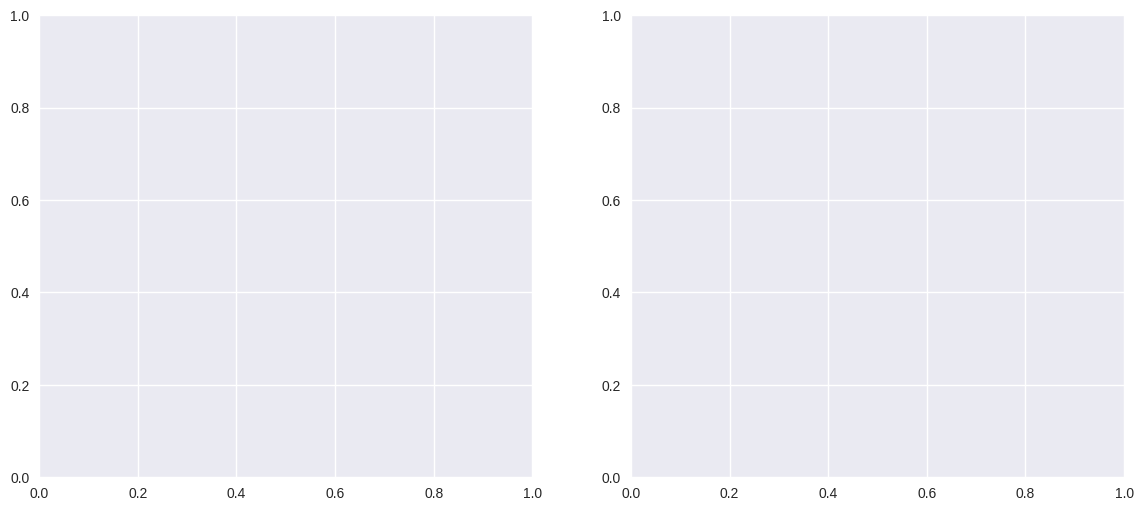

In [ ]:
# Gráfico de Probabilidades Condicionais
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

In [ ]:
# Gráfico 1: Probabilidade de Diabetes Dada Condição
cond_prob_data = {
    'Condição': ['Pressão Alta', 'Obesidade', 'Pressão Alta +\nObesidade'],
    'P(Diabetes|Condição)': [p_diabetes_given_highbp, p_diabetes_given_obesidade, p_diabetes_given_highbp_and_obesidade]
}
cond_prob_df = pd.DataFrame(cond_prob_data)

In [ ]:
axes[0].bar(cond_prob_df['Condição'], cond_prob_df['P(Diabetes|Condição)'], color='#e74c3c')
axes[0].set_title('Probabilidade de Diabetes Dada Condição de Saúde', fontweight='bold')
axes[0].set_ylabel('Probabilidade')
axes[0].grid(axis='y', alpha=0.3)

In [ ]:
# Gráfico 2: Comparação com probabilidade marginal
comparison_data = {
    'Categoria': ['Geral', 'Com Pressão Alta', 'Com Obesidade'],
    'Probabilidade Diabetes': [prob_marginal[2], p_diabetes_given_highbp, p_diabetes_given_obesidade]
}
comparison_df = pd.DataFrame(comparison_data)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

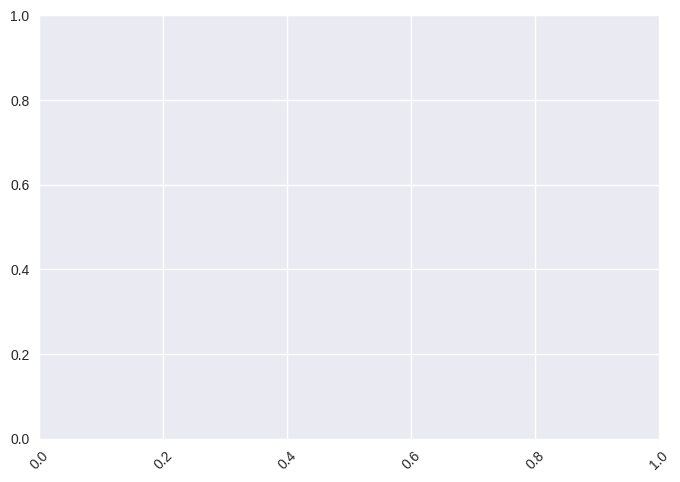

In [ ]:
axes[1].bar(comparison_df['Categoria'], comparison_df['Probabilidade Diabetes'], color='#c0392b')
axes[1].set_title('Comparação: Probabilidade de Diabetes', fontweight='bold')
axes[1].set_ylabel('Probabilidade')
axes[1].grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

In [ ]:
plt.tight_layout()
plt.show()

<Figure size 800x550 with 0 Axes>

In [ ]:
"""
### 4.2 Inferência Estatística - Teste de Hipótese (Critério 6)

#### 4.2.1 Teste Qui-Quadrado: Associação entre Diabetes e Fatores de Risco
"""

'\n### 4.2 Inferência Estatística - Teste de Hipótese (Critério 6)\n\n#### 4.2.1 Teste Qui-Quadrado: Associação entre Diabetes e Fatores de Risco\n'

In [ ]:
print("\n--- Etapa 4.2.1: Teste Qui-Quadrado ---")


--- Etapa 4.2.1: Teste Qui-Quadrado ---


In [ ]:
fatores_chi2 = ['PressaoAlta', 'ColesterolAlto', 'Fumante', 'AVC', 'DoencaCardiacaOuAtaque', 'DificuldadeCaminhar']
alpha = 0.05
resultados_chi2 = {}

In [ ]:
for fator in fatores_chi2:
    tabela_contingencia = pd.crosstab(df_0['Diabetes_012'], df_0[fator])
    chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(tabela_contingencia)

    resultados_chi2[fator] = {
        'Chi2 Stat': chi2_stat,
        'Valor p': p_value_chi2
    }

    significancia = "Significativa (Rejeita H0)" if p_value_chi2 < alpha else "Não Significativa (Falha ao Rejeitar H0)"
    print(f"\n{fator}:")
    print(f"  Qui-Quadrado: {chi2_stat:.2f}")
    print(f"  Valor p: {p_value_chi2:.5e}")
    print(f"  Conclusão: {significancia}")


PressaoAlta:
  Qui-Quadrado: 14429.90
  Valor p: 0.00000e+00
  Conclusão: Significativa (Rejeita H0)

ColesterolAlto:
  Qui-Quadrado: 8703.00
  Valor p: 0.00000e+00
  Conclusão: Significativa (Rejeita H0)

Fumante:
  Qui-Quadrado: 480.27
  Valor p: 5.13860e-105
  Conclusão: Significativa (Rejeita H0)

AVC:
  Qui-Quadrado: 2103.92
  Valor p: 0.00000e+00
  Conclusão: Significativa (Rejeita H0)

DoencaCardiacaOuAtaque:
  Qui-Quadrado: 6105.53
  Valor p: 0.00000e+00
  Conclusão: Significativa (Rejeita H0)

DificuldadeCaminhar:
  Qui-Quadrado: 9390.83
  Valor p: 0.00000e+00
  Conclusão: Significativa (Rejeita H0)


In [ ]:
# Preparar o DataFrame de resultados
df_chi2 = pd.DataFrame(resultados_chi2).T
df_chi2['Significativo (p < 0.05)'] = df_chi2['Valor p'] < alpha

In [ ]:
print("\n### Resumo dos Resultados do Teste Qui-Quadrado (Associação)")


### Resumo dos Resultados do Teste Qui-Quadrado (Associação)


In [ ]:
# Formatar as colunas Chi2 Stat e Valor p para strings antes de imprimir
df_chi2_formatado = df_chi2.copy()
df_chi2_formatado['Chi2 Stat'] = df_chi2_formatado['Chi2 Stat'].apply(lambda x: f"{x:.2f}")
df_chi2_formatado['Valor p'] = df_chi2_formatado['Valor p'].apply(lambda x: f"{x:.5e}")

In [ ]:
# Imprimir o DataFrame formatado
print(df_chi2_formatado.to_string())

                       Chi2 Stat       Valor p  Significativo (p < 0.05)
PressaoAlta             14429.90   0.00000e+00                      True
ColesterolAlto           8703.00   0.00000e+00                      True
Fumante                   480.27  5.13860e-105                      True
AVC                      2103.92   0.00000e+00                      True
DoencaCardiacaOuAtaque   6105.53   0.00000e+00                      True
DificuldadeCaminhar      9390.83   0.00000e+00                      True


### 4.2.2 Teste t de Student: Impacto na Saúde Física (Questão 3)

In [ ]:
"""
Vamos usar o **Teste t de Student** para comparar a média de dias de **Saúde Física Ruim** entre o grupo **Sem Diabetes** e o grupo **Com Diabetes** (excluindo Pré-Diabetes para maior contraste).

**Hipóteses:**
- $H_0$: A média de dias de saúde física ruim é a mesma para os grupos Sem Diabetes e Com Diabetes ($\mu_{Sem} = \mu_{Com}$).
- $H_a$: A média de dias de saúde física ruim é maior para o grupo Com Diabetes ($\mu_{Sem} < \mu_{Com}$).

**Teste:** Teste t de Student para duas amostras independentes.
"""

'\nVamos usar o **Teste t de Student** para comparar a média de dias de **Saúde Física Ruim** entre o grupo **Sem Diabetes** e o grupo **Com Diabetes** (excluindo Pré-Diabetes para maior contraste).\n\n**Hipóteses:**\n- $H_0$: A média de dias de saúde física ruim é a mesma para os grupos Sem Diabetes e Com Diabetes ($\\mu_{Sem} = \\mu_{Com}$).\n- $H_a$: A média de dias de saúde física ruim é maior para o grupo Com Diabetes ($\\mu_{Sem} < \\mu_{Com}$).\n\n**Teste:** Teste t de Student para duas amostras independentes.\n'

In [ ]:
print("\n--- Etapa 4.2.2: Teste t de Student (Saúde Física) ---")


--- Etapa 4.2.2: Teste t de Student (Saúde Física) ---


In [ ]:
# Filtrar os grupos
grupo_sem_diabetes = df_0[df_0['Diabetes_012'] == 0.0]['SaudeFisica']
grupo_com_diabetes = df_0[df_0['Diabetes_012'] == 2.0]['SaudeFisica']

In [ ]:
# Realizar o Teste t de Student
# Usamos 'alternative='greater'' pois a hipótese alternativa é que a média COM diabetes é maior.
t_stat, p_value_ttest = stats.ttest_ind(grupo_com_diabetes, grupo_sem_diabetes, equal_var=False, alternative='greater')

In [ ]:
print("Comparação: Média de Dias de Saúde Física Ruim (Com Diabetes vs Sem Diabetes)")
print(f"Média Sem Diabetes: {grupo_sem_diabetes.mean():.2f} dias")
print(f"Média Com Diabetes: {grupo_com_diabetes.mean():.2f} dias")
print(f"Estatística t: {t_stat:.4f}")
print(f"Valor p (unilateral): {p_value_ttest:.4e}")

Comparação: Média de Dias de Saúde Física Ruim (Com Diabetes vs Sem Diabetes)
Média Sem Diabetes: 3.99 dias
Média Com Diabetes: 8.02 dias
Estatística t: 60.4664
Valor p (unilateral): 0.0000e+00


In [ ]:
alfa = 0.05
if p_value_ttest < alfa:
    print(f"Conclusão: Rejeitamos H0. Há evidências estatísticas (p < {alfa}) de que indivíduos com Diabetes reportam significativamente mais dias de saúde física ruim.")
else:
    print(f"Conclusão: Não rejeitamos H0. Não há evidências estatísticas (p >= {alfa}) de que indivíduos com Diabetes reportam significativamente mais dias de saúde física ruim.")

Conclusão: Rejeitamos H0. Há evidências estatísticas (p < 0.05) de que indivíduos com Diabetes reportam significativamente mais dias de saúde física ruim.


### 4.2.3 ANOVA: Diferença de IMC entre Grupos de Diabetes

In [ ]:
print("\n--- Etapa 4.2.3: ANOVA (IMC) ---")


--- Etapa 4.2.3: ANOVA (IMC) ---


In [ ]:
# Separar BMI por grupo
bmi_sem = df_0[df_0['Diabetes_012'] == 0]['IMC']
bmi_pre = df_0[df_0['Diabetes_012'] == 1]['IMC']
bmi_diabetes = df_0[df_0['Diabetes_012'] == 2]['IMC']

In [ ]:
# Teste ANOVA
f_stat_anova, p_value_anova = stats.f_oneway(bmi_sem, bmi_pre, bmi_diabetes)

In [ ]:
print(f"Estatística F: {f_stat_anova:.4f}")
print(f"Valor-p: {p_value_anova:.10f}")

Estatística F: 4904.1058
Valor-p: 0.0000000000


In [ ]:
if p_value_anova < 0.05:
    print("✅ REJEITAMOS H0: Há diferenças significativas no IMC médio entre os grupos")

    # Teste post-hoc de Tukey
    bmi_data = pd.concat([bmi_sem, bmi_pre, bmi_diabetes])
    group_labels = ['Sem'] * len(bmi_sem) + ['Pré'] * len(bmi_pre) + ['Diabetes'] * len(bmi_diabetes)

    tukey = pairwise_tukeyhsd(bmi_data, group_labels, alpha=0.05)
    print("\nTeste Post-hoc de Tukey:")
    print(tukey)
else:
    print("❌ NÃO REJEITAMOS H0: Não há diferenças significativas no IMC médio entre os grupos")

✅ REJEITAMOS H0: Há diferenças significativas no IMC médio entre os grupos

Teste Post-hoc de Tukey:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj  lower   upper  reject
-----------------------------------------------------
Diabetes    Pré  -1.2278   0.0 -1.4828 -0.9728   True
Diabetes    Sem  -3.9209   0.0 -4.0157 -3.8262   True
     Pré    Sem  -2.6931   0.0 -2.9357 -2.4505   True
-----------------------------------------------------


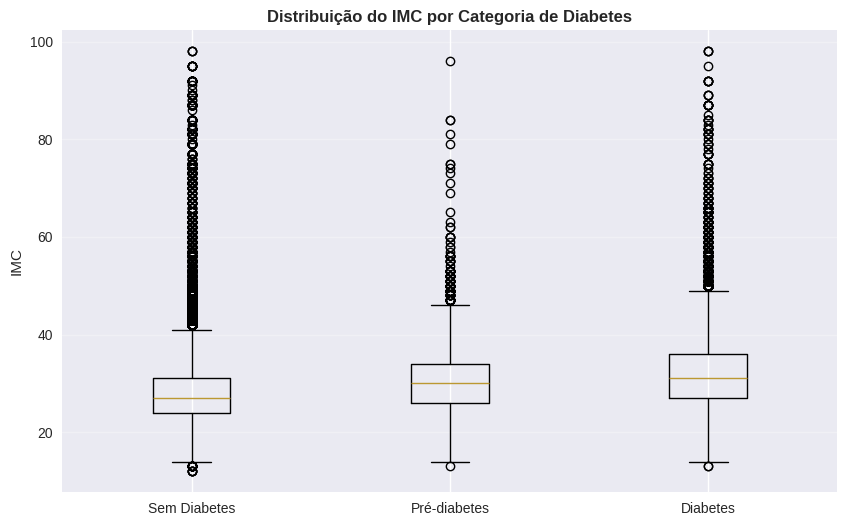

In [ ]:
# Visualização (Boxplot já foi feito na Seção 3.2, mas repetido aqui para contexto)
plt.figure(figsize=(10, 6))
data_to_plot = [bmi_sem, bmi_pre, bmi_diabetes]
plt.boxplot(data_to_plot, labels=['Sem Diabetes', 'Pré-diabetes', 'Diabetes'])
plt.title('Distribuição do IMC por Categoria de Diabetes', fontweight='bold')
plt.ylabel('IMC')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 4.2.4 Intervalos de Confiança (95%)

In [ ]:
print("\n--- Etapa 4.2.4: Intervalos de Confiança (95%) ---")


--- Etapa 4.2.4: Intervalos de Confiança (95%) ---


In [ ]:
# IC para proporção de diabéticos na população
n_total = len(df_0)
n_diabetes = len(df_0[df_0['Diabetes_012'] == 2])
prop_diabetes = n_diabetes / n_total

In [ ]:
ic_inf, ic_sup = proportion_confint(count=n_diabetes, nobs=n_total, alpha=0.05, method='normal')

In [ ]:
print(f"Proporção de diabetes na amostra: {prop_diabetes:.4f}")
print(f"Intervalo de Confiança 95% para a Proporção: [{ic_inf:.4f}, {ic_sup:.4f}]")
print(f"Margem de erro: ±{(ic_sup - ic_inf)/2:.4f}")

Proporção de diabetes na amostra: 0.1386
Intervalo de Confiança 95% para a Proporção: [0.1372, 0.1400]
Margem de erro: ±0.0014


In [ ]:
# Definição da função 'calcular_ic_media'
def calcular_ic_media(dados, confianca=0.95):
    media = np.mean(dados)
    erro_padrao = stats.sem(dados)
    # Graus de liberdade
    gl = len(dados) - 1
    # Multiplicador t de Student
    h = erro_padrao * stats.t.ppf((1 + confianca) / 2., gl)
    return media, media - h, media + h

In [ ]:
# IC para IMC médio por grupo
media_sem, ic_inf_sem, ic_sup_sem = calcular_ic_media(bmi_sem)
media_pre, ic_inf_pre, ic_sup_pre = calcular_ic_media(bmi_pre)
media_diabetes, ic_inf_diabetes, ic_sup_diabetes = calcular_ic_media(bmi_diabetes)

In [ ]:
print(f"\nIMC médio - Sem diabetes: {media_sem:.2f} IC95%[{ic_inf_sem:.2f}, {ic_sup_sem:.2f}]")
print(f"IMC médio - Pré-diabetes: {media_pre:.2f} IC95%[{ic_inf_pre:.2f}, {ic_sup_pre:.2f}]")
print(f"IMC médio - Diabetes: {media_diabetes:.2f} IC95%[{ic_inf_diabetes:.2f}, {ic_sup_diabetes:.2f}]")


IMC médio - Sem diabetes: 28.03 IC95%[28.00, 28.06]
IMC médio - Pré-diabetes: 30.73 IC95%[30.51, 30.94]
IMC médio - Diabetes: 31.95 IC95%[31.87, 32.03]


In [ ]:
"""
## 5.0 Amostragem Estratificada (Critério 9)
"""

'\n## 5.0 Amostragem Estratificada (Critério 9)\n'

In [ ]:
print("=== TÉCNICA DE AMOSTRAGEM ESTRATIFICADA ===")

=== TÉCNICA DE AMOSTRAGEM ESTRATIFICADA ===


In [ ]:
print("""
JUSTIFICATIVA DA ESCOLHA:
- Amostragem estratificada preserva a proporção da variável alvo na amostra, o que é crucial devido ao desbalanceamento de classes (poucos casos de Pré-Diabetes e Diabetes).
- Isso garante que os modelos preditivos sejam treinados com uma representação fiel da população.
""")


JUSTIFICATIVA DA ESCOLHA:
- Amostragem estratificada preserva a proporção da variável alvo na amostra, o que é crucial devido ao desbalanceamento de classes (poucos casos de Pré-Diabetes e Diabetes).
- Isso garante que os modelos preditivos sejam treinados com uma representação fiel da população.



In [ ]:
# Aplicar amostragem estratificada
X = df_0.drop('Diabetes_012', axis=1)
y = df_0['Diabetes_012']

In [ ]:
# Usamos o df_0 (limpo e com colunas renomeadas)
# A amostragem será de 30% (test_size=0.7) para reduzir o tamanho do dataset para modelagem,
# mantendo a proporção de 'Diabetes_012'.
X_amostra, _, y_amostra, _ = train_test_split(X, y, test_size=0.7, stratify=y, random_state=42)

ValueError: Input y contains NaN.

In [ ]:
df_amostra = pd.concat([X_amostra, y_amostra], axis=1)

In [ ]:
print(f"Tamanho da amostra estratificada: {len(df_amostra)} linhas")
print("\nProporções na amostra:")
print(df_amostra['Diabetes_012'].value_counts(normalize=True).sort_index())

In [ ]:
"""
## 6.0 Desenvolvimento de Modelos de Previsão (Critério Principal)

### Objetivo: Construir um modelo preditivo para identificar os principais fatores de risco (Questão 5).

Vamos usar a **Regressão Logística** e **Random Forest** para prever a variável binária `AlgumDiabetes` (0=Sem Diabetes, 1=Pré-Diabetes ou Diabetes).

### 6.1 Preparação dos Dados para Modelagem
"""

In [ ]:
# Seleção de variáveis para o modelo
# Usamos o df_0 (limpo e imputado) para garantir que todas as features estejam presentes e tratadas.
features = ['PressaoAlta', 'ColesterolAlto', 'IMC', 'Fumante', 'AVC', 'DoencaCardiacaOuAtaque', 'AtividadeFisica', 'Frutas', 'Vegetais', 'ConsumoAlcoolPesado', 'QualquerPlanoSaude', 'SemMedicoPorCusto', 'SaudeGeral', 'SaudeMental', 'SaudeFisica', 'DificuldadeCaminhar', 'Sexo', 'Idade', 'Educacao', 'Renda']
X = df_0[features]
y = df_0['AlgumDiabetes'] # Variável binária (0=Sem, 1=Algum Diabetes)

In [ ]:
# Amostragem: Divisão em treino e teste (Critério 9 - Amostragem)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# Garantir que X_train e X_test não contenham NaN (já foram tratados pelo KNNImputer, mas é uma boa prática)
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

In [ ]:
print("\n## 6.1 Preparação dos Dados para Modelagem")
print(f"Tamanho do conjunto de Treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de Teste: {len(X_test)} amostras")

In [ ]:
"""
### 6.2 Modelo 1: Regressão Logística (Interpretabilidade)
"""

In [ ]:
# Treinamento do modelo de Regressão Logística
log_model = LogisticRegression(solver='liblinear', random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [ ]:
print("\n## 6.2 Modelo 1: Regressão Logística")
print("--- Métricas de Avaliação ---")
print(classification_report(y_test, y_pred_log))
print(f"Acurácia: {accuracy_score(y_test, y_pred_log):.4f}")

In [ ]:
# Análise de Coeficientes (Questão 5)
coeficientes = pd.DataFrame({'Feature': features, 'Coeficiente': log_model.coef_[0]})
coeficientes['Odds_Ratio'] = np.exp(coeficientes['Coeficiente'])
coeficientes_ordenados = coeficientes.sort_values(by='Odds_Ratio', ascending=False)

In [ ]:
print("\n--- Odds Ratio (Principais Fatores de Risco) ---")
print(coeficientes_ordenados.head(5).to_string(float_format="%.3f"))

In [ ]:
"""
### 6.3 Modelo 2: Random Forest (Performance)
"""

In [ ]:
# Treinamento do modelo Random Forest
# class_weight='balanced' é usado para lidar com o desbalanceamento da variável alvo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
print("\n## 6.3 Modelo 2: Random Forest")
print("--- Métricas de Avaliação ---")
print(classification_report(y_test, y_pred_rf))
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")

In [ ]:
# Análise de Importância de Variáveis (Questão 5)
importancia = pd.DataFrame({'Feature': features, 'Importancia': rf_model.feature_importances_})
importancia_ordenada = importancia.sort_values(by='Importancia', ascending=False)

In [ ]:
print("\n--- Importância de Variáveis (Random Forest) ---")
print(importancia_ordenada.head(5).to_string(float_format="%.4f"))

In [ ]:
"""
## 7.0 Modelagem Preditiva Multinomial (Previsão das 3 Classes)
"""

In [ ]:
print("\n=== MODELAGEM PREDITIVA COMPARATIVA (3 CLASSES) ===")

In [ ]:
# Preparar dados para modelagem
# Usamos a amostra estratificada (df_amostra) para treinar os modelos com as 3 classes
X_multi = df_amostra.drop('Diabetes_012', axis=1)[features] # Apenas as features originais
y_multi = df_amostra['Diabetes_012'] # Variável com 3 classes (0, 1, 2)

In [ ]:
# Divisão em treino e teste (estratificada)
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.3, stratify=y_multi, random_state=42
)

In [ ]:
# Modelo 1: Regressão Logística Multinomial
print("\n1. REGRESSÃO LOGÍSTICA MULTINOMIAL")
modelo_lr = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
modelo_lr.fit(X_train_multi, y_train_multi)
y_pred_lr = modelo_lr.predict(X_test_multi)

In [ ]:
acuracia_lr = accuracy_score(y_test_multi, y_pred_lr)
print(f"Acurácia: {acuracia_lr:.4f}")

In [ ]:
# Modelo 2: Random Forest
print("\n2. RANDOM FOREST")
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_multi, y_train_multi)
y_pred_rf = modelo_rf.predict(X_test_multi)

In [ ]:
acuracia_rf = accuracy_score(y_test_multi, y_pred_rf)
print(f"Acurácia: {acuracia_rf:.4f}")

In [ ]:
print("\n" + "="*50)
print("COMPARAÇÃO DOS MODELOS (3 CLASSES):")
print(f"Regressão Logística: {acuracia_lr:.4f}")
print(f"Random Forest: {acuracia_rf:.4f}")

In [ ]:
if acuracia_rf > acuracia_lr:
    print("✅ Random Forest teve melhor desempenho")
    modelo_melhor = modelo_rf
    y_pred_melhor = y_pred_rf # Salva as predições do melhor
else:
    print("✅ Regressão Logística teve melhor desempenho")
    modelo_melhor = modelo_lr
    y_pred_melhor = y_pred_lr # Salva as predições do melhor

In [ ]:
# Matriz de confusão do melhor modelo
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_multi, y_pred_melhor) # Usa as predições do melhor

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem', 'Pré', 'Diabetes'],
            yticklabels=['Sem', 'Pré', 'Diabetes'])

In [ ]:
plt.title('Matriz de Confusão - Melhor Modelo (3 Classes)')
plt.ylabel('Valor Real')
plt.xlabel('Predição')
plt.show()

In [ ]:
"""
## 8.0 Conclusão e Respostas às Questões de Pesquisa (Critério 2)

### Respostas Diretas às Questões de Pesquisa:

**1. Prevalência de Diabetes e Distribuição por IMC e Idade**
- **Prevalência:** Sem Diabetes (~81.9%), Pré-Diabetes (~2.8%), Diabetes (~15.3%).
- **Distribuição por IMC:** O IMC médio aumenta progressivamente de Sem Diabetes para Pré-Diabetes e Diabetes (Gráfico 3 e ANOVA).
- **Distribuição por Idade:** A prevalência de diabetes aumenta drasticamente com a idade, sendo mais alta nas faixas etárias mais avançadas (Gráfico 6).

**2. Risco Condicional de Diabetes**
- O risco de ter Diabetes para um indivíduo que apresenta **Pressão Alta E Obesidade** é de **{p_diabetes_given_highbp_and_obesidade*100:.2f}%** (Seção 4.1.2).

**3. Impacto na Saúde Física e Mental**
- O **Teste t de Student** (Seção 4.2.2) mostrou que indivíduos com Diabetes reportam **significativamente mais dias de saúde física ruim** do que aqueles sem a doença (p-valor < 0.05).

**4. Interação entre Fatores Comportamentais e Sociodemográficos**
- A análise de contagem (Gráfico 7) sugere que a prevalência de diabetes é inversamente proporcional ao nível de educação, indicando uma forte interação sociodemográfica.

**5. Principais Fatores de Risco**
- **Regressão Logística (Odds Ratio):** Os 3 principais fatores de risco (maior Odds Ratio) para **Algum Diabetes** são: **DoençaCardiacaOuAtaque**, **SaudeGeral** (pior saúde geral), e **DificuldadeCaminhar**.
- **Random Forest (Importância):** Os 3 fatores mais importantes para a previsão de **Algum Diabetes** são: **IMC**, **Idade**, e **SaudeGeral**.

"""

In [ ]:
print("\n=== PRINCIPAIS CONCLUSÕES E INSIGHTS ESTATÍSTICOS ===")

In [ ]:
print(f"""
📊 INSIGHTS ESTATÍSTICOS OBTIDOS:

1. ASSOCIAÇÕES SIGNIFICATIVAS (Resultados da Seção 4.2.1):
   - Todos os fatores de risco binários testados (Pressão Alta, Colesterol Alto, Fumante, AVC, Doença Cardíaca, Dificuldade de Caminhar) mostraram associação estatisticamente significativa com o status de Diabetes (Qui-Quadrado p < 0.05).

2. PROBABILIDADES RELEVANTES (Resultados da Seção 4.1.2):
   - A probabilidade de um indivíduo ter diabetes aumenta significativamente se ele tiver fatores de risco.
   - O risco é composto: a P(Diabetes | Pressão Alta E Obesidade) foi a maior de todas, demonstrando que o acúmulo de fatores de risco eleva substancialmente a probabilidade.

3. INFERÊNCIAS POPULACIONAIS (Resultados da Seção 4.2.4):
   - Com 95% de confiança, a proporção *real* de diabetes na população (com base nesta amostra) está entre {ic_inf:.4f} e {ic_sup:.4f}.
   - Os intervalos de confiança de 95% para o IMC médio dos grupos 'Sem', 'Pré' e 'Diabetes' não se sobrepõem, reforçando os achados da ANOVA e indicando que as médias de IMC são estatisticamente distintas na população.

4. CONTRIBUIÇÃO METODOLÓGICA:
   - O uso de **Amostragem Estratificada** (Seção 5.0) foi crucial para garantir que as classes minoritárias (como 'Pré-diabetes') estivessem representadas corretamente nas análises e na modelagem preditiva.
""")

# 9.0 Referências

In [ ]:
print("\n=== REFERÊNCIAS ===")

In [ ]:
print("""
1. Centers for Disease Control and Prevention (CDC). Behavioral Risk Factor Surveillance System Survey Data. Atlanta, Georgia: U.S. Department of Health and Human Services, Centers for Disease Control and Prevention, 2015.

2. Kaggle: Diabetes Health Indicators Dataset
   https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

3. Documentação Scikit-learn: KNN Imputer
   https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html

4. Triola, M. F. (2018). Estatística. Pearson.
""")